# AIDev PR Activity Exploration

Notebook inicial para cruzar `pull_request`, `pr_commits` y `pr_reviews` del dataset `hao-li/AIDev`.

Objetivos de este primer análisis:
- cargar los tres subsets base desde los Parquet oficiales;
- construir una tabla resumen por PR;
- levantar métricas simples alineadas con el proyecto;
- generar gráficos exploratorios sobre merge, commits y revisiones.


## 1. Dependencias

Ejecuta esta celda si tu entorno todavía no tiene `pandas`, `pyarrow`, `matplotlib` y `seaborn`.


In [ ]:
%pip install -r ../requirements-notebook.txt


## 2. Imports y helper functions


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "exploration" / "aidev" / "pr_activity.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "exploration" / "aidev" / "pr_activity.py").exists():
    raise FileNotFoundError("No se encontró el proyecto raíz desde el notebook.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from exploration.aidev.pr_activity import (
    build_pr_activity_records,
    compute_overview_metrics,
    get_parquet_urls,
)

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="deep")


## 3. Cargar datos desde Parquet

Estos tres subsets son la base mínima para un primer intento orientado a autonomía, revisión e integración de PRs.


In [3]:
CONFIGS = ["pull_request", "pr_commits", "pr_reviews"]
urls = get_parquet_urls(CONFIGS)
urls


{'pr_commits': 'https://huggingface.co/datasets/hao-li/AIDev/resolve/refs%2Fconvert%2Fparquet/pr_commits/train/0000.parquet',
 'pr_reviews': 'https://huggingface.co/datasets/hao-li/AIDev/resolve/refs%2Fconvert%2Fparquet/pr_reviews/train/0000.parquet',
 'pull_request': 'https://huggingface.co/datasets/hao-li/AIDev/resolve/refs%2Fconvert%2Fparquet/pull_request/train/0000.parquet'}

In [4]:
pull_request_df = pd.read_parquet(urls["pull_request"])
pr_commits_df = pd.read_parquet(urls["pr_commits"])
pr_reviews_df = pd.read_parquet(urls["pr_reviews"])

shape_summary = pd.DataFrame({
    "rows": [len(pull_request_df), len(pr_commits_df), len(pr_reviews_df)],
    "columns": [pull_request_df.shape[1], pr_commits_df.shape[1], pr_reviews_df.shape[1]],
}, index=["pull_request", "pr_commits", "pr_reviews"])
shape_summary


,rows,columns
pull_request,33596,14
pr_commits,88576,5
pr_reviews,28875,7


In [5]:
schema_preview = {
    "pull_request": list(pull_request_df.columns),
    "pr_commits": list(pr_commits_df.columns),
    "pr_reviews": list(pr_reviews_df.columns),
}
schema_preview


{'pull_request': ['id',
  'number',
  'title',
  'body',
  'agent',
  'user_id',
  'user',
  'state',
  'created_at',
  'closed_at',
  'merged_at',
  'repo_id',
  'repo_url',
  'html_url'],
 'pr_commits': ['sha', 'pr_id', 'author', 'committer', 'message'],
 'pr_reviews': ['id',
  'pr_id',
  'user',
  'user_type',
  'state',
  'submitted_at',
  'body']}

## 4. Construir tabla resumen por PR

El cruce se hace sobre `pull_request.id == pr_commits.pr_id == pr_reviews.pr_id`.


In [6]:
activity_records = build_pr_activity_records(
    pull_request_df.to_dict("records"),
    pr_commits_df.to_dict("records"),
    pr_reviews_df.to_dict("records"),
)
activity_df = pd.DataFrame(activity_records)
activity_df.head()


,pr_id,number,agent,author,state,merged,repo_id,repo_url,html_url,created_at,closed_at,merged_at,commit_count,unique_commit_authors_count,external_commit_author_count,review_count,unique_reviewers_count,human_review_count,bot_review_count,approved_review_count,changes_requested_review_count,commented_review_count,has_human_review,has_external_human_review,time_to_close_hours,time_to_merge_hours
0,2756921963,603,Devin,devin-ai-integration[bot],closed,False,679017521,https://api.github.com/repos/AgentOps-AI/agentops,https://github.com/AgentOps-AI/agentops/pull/603,2024-12-24T00:23:09Z,2025-01-09T11:13:02Z,None,16,1,0,30,1,0,30,0,0,30,False,False,394.831389,NaN
1,2757103560,6402,Devin,devin-ai-integration[bot],closed,False,430749584,https://api.github.com/repos/OneKeyHQ/app-mono...,https://github.com/OneKeyHQ/app-monorepo/pull/...,2024-12-24T03:28:51Z,2024-12-25T01:50:06Z,None,10,1,0,0,0,0,0,0,0,0,False,False,22.354167,NaN
2,2757124156,38335,Devin,devin-ai-integration[bot],closed,False,275993885,https://api.github.com/repos/appsmithorg/appsmith,https://github.com/appsmithorg/appsmith/pull/3...,2024-12-24T03:56:34Z,2025-01-07T16:43:35Z,None,1,1,0,0,0,0,0,0,0,0,False,False,348.783611,NaN
3,2757125491,38336,Devin,devin-ai-integration[bot],closed,False,275993885,https://api.github.com/repos/appsmithorg/appsmith,https://github.com/appsmithorg/appsmith/pull/3...,2024-12-24T03:58:41Z,2025-01-07T16:43:33Z,None,1,1,0,0,0,0,0,0,0,0,False,False,348.747778,NaN
4,2757179026,38339,Devin,devin-ai-integration[bot],closed,False,275993885,https://api.github.com/repos/appsmithorg/appsmith,https://github.com/appsmithorg/appsmith/pull/3...,2024-12-24T05:00:11Z,2025-01-07T16:43:32Z,None,6,2,1,0,0,0,0,0,0,0,False,False,347.722500,NaN


In [7]:
overview_metrics = pd.DataFrame([compute_overview_metrics(activity_records)]).T
overview_metrics.columns = ["value"]
overview_metrics


,value
total_prs,33596.000000
merged_prs,24014.000000
merge_rate,0.714787
avg_commits_per_pr,2.636504
avg_reviews_per_pr,0.859477
prs_with_human_reviews,6004.000000
prs_with_external_human_reviews,5739.000000
prs_with_bot_reviews,4534.000000
avg_time_to_close_hours,40.430300
avg_time_to_merge_hours,19.430361


## 5. Variables derivadas para visualización


In [8]:
activity_df["merge_label"] = activity_df["merged"].map({True: "Merged", False: "Not merged"})

def classify_review_signal(row):
    if row["has_external_human_review"]:
        return "Con revisión humana externa"
    if row["has_human_review"]:
        return "Review humana del autor"
    if row["bot_review_count"] > 0:
        return "Solo revisión bot"
    return "Sin reviews"

activity_df["review_signal"] = activity_df.apply(classify_review_signal, axis=1)
activity_df[["pr_id", "agent", "merged", "review_signal", "commit_count", "review_count"]].head()


,pr_id,agent,merged,review_signal,commit_count,review_count
0,2756921963,Devin,False,Solo revisión bot,16,30
1,2757103560,Devin,False,Sin reviews,10,0
2,2757124156,Devin,False,Sin reviews,1,0
3,2757125491,Devin,False,Sin reviews,1,0
4,2757179026,Devin,False,Sin reviews,6,0


## 6. Gráficos básicos


In [9]:
agent_summary = (
    activity_df.groupby("agent", dropna=False)
    .agg(
        pr_count=("pr_id", "count"),
        merge_rate=("merged", "mean"),
        avg_commit_count=("commit_count", "mean"),
        avg_review_count=("review_count", "mean"),
    )
    .sort_values("pr_count", ascending=False)
    .head(10)
    .reset_index()
)
agent_summary


,agent,pr_count,merge_rate,avg_commit_count,avg_review_count
0,OpenAI_Codex,21799,0.825909,1.492179,0.212212
1,Copilot,4970,0.430382,4.791348,3.235815
2,Devin,4827,0.537601,4.823079,1.187487
3,Cursor,1541,0.652174,4.005840,1.159637
4,Claude_Code,459,0.590414,6.058824,1.411765


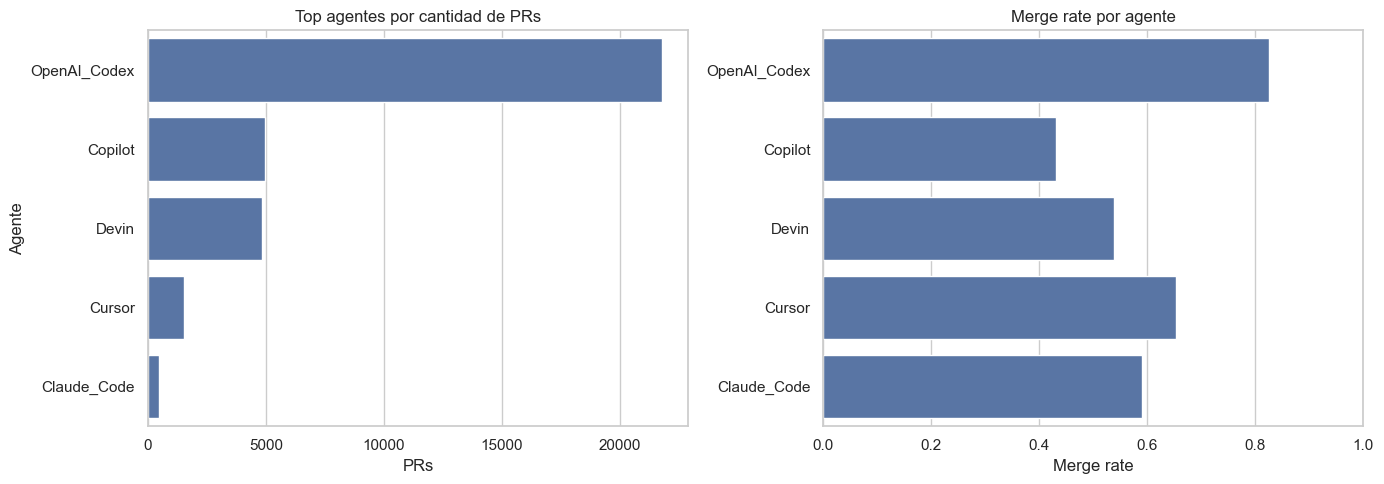

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=agent_summary, x="pr_count", y="agent", ax=axes[0])
axes[0].set_title("Top agentes por cantidad de PRs")
axes[0].set_xlabel("PRs")
axes[0].set_ylabel("Agente")

sns.barplot(data=agent_summary, x="merge_rate", y="agent", ax=axes[1])
axes[1].set_title("Merge rate por agente")
axes[1].set_xlabel("Merge rate")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 1)

plt.tight_layout()


In [11]:
review_signal_summary = (
    activity_df.groupby("review_signal")
    .agg(
        pr_count=("pr_id", "count"),
        merge_rate=("merged", "mean"),
        avg_review_count=("review_count", "mean"),
    )
    .sort_values("pr_count", ascending=False)
    .reset_index()
)
review_signal_summary


,review_signal,pr_count,merge_rate,avg_review_count
0,Sin reviews,25456,0.710324,0.000000
1,Con revisión humana externa,5739,0.759714,4.296393
2,Solo revisión bot,2136,0.637640,1.630618
3,Review humana del autor,265,0.792453,2.773585


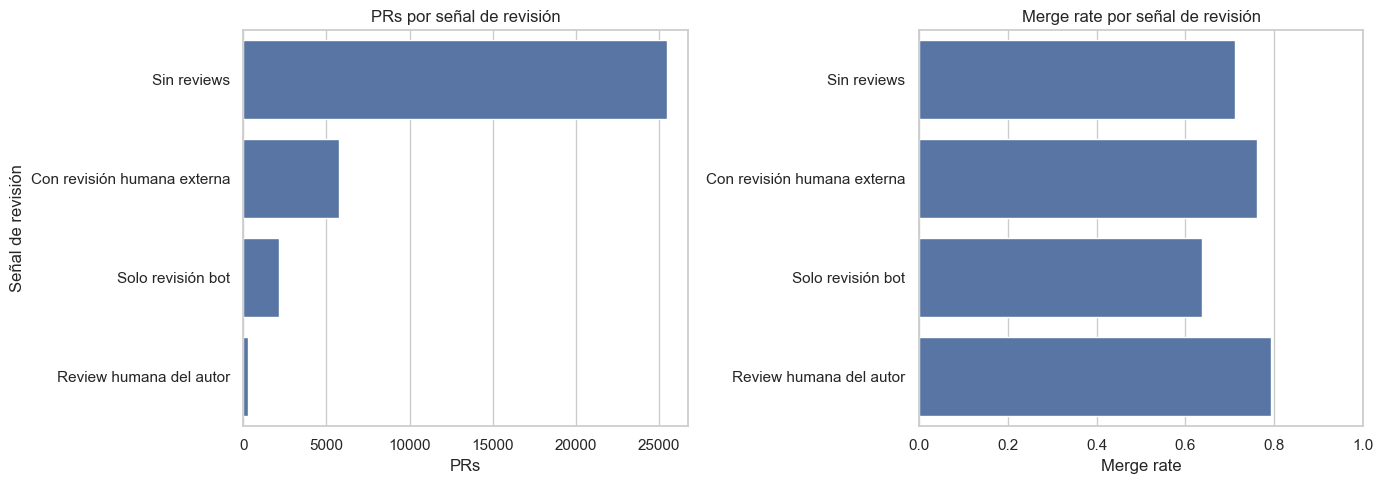

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=review_signal_summary, x="pr_count", y="review_signal", ax=axes[0])
axes[0].set_title("PRs por señal de revisión")
axes[0].set_xlabel("PRs")
axes[0].set_ylabel("Señal de revisión")

sns.barplot(data=review_signal_summary, x="merge_rate", y="review_signal", ax=axes[1])
axes[1].set_title("Merge rate por señal de revisión")
axes[1].set_xlabel("Merge rate")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 1)

plt.tight_layout()


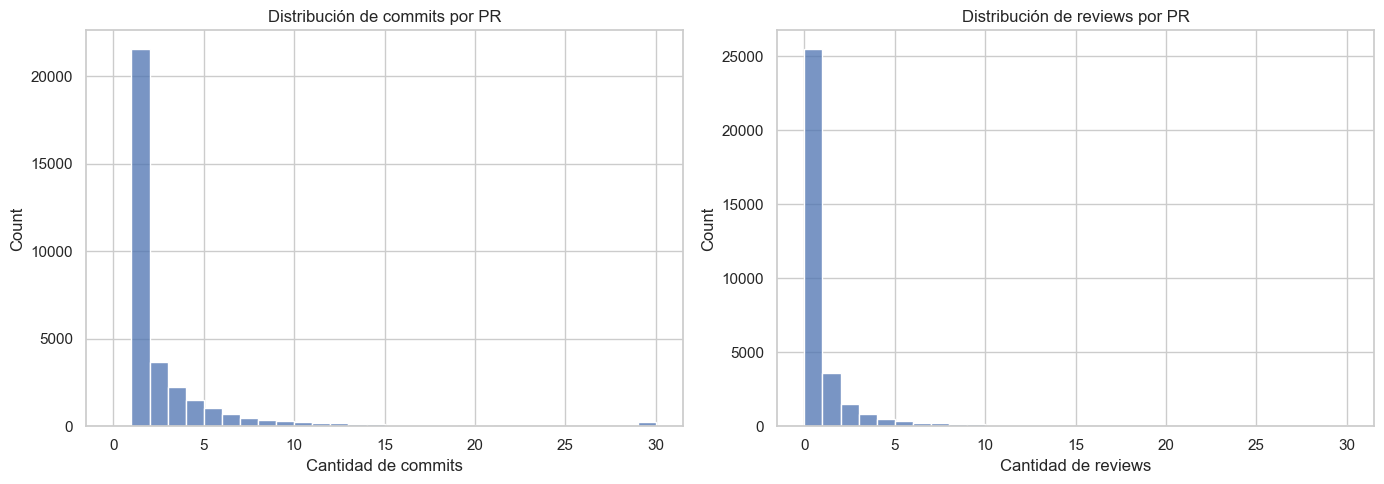

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(activity_df["commit_count"], bins=30, ax=axes[0])
axes[0].set_title("Distribución de commits por PR")
axes[0].set_xlabel("Cantidad de commits")

sns.histplot(activity_df["review_count"], bins=30, ax=axes[1])
axes[1].set_title("Distribución de reviews por PR")
axes[1].set_xlabel("Cantidad de reviews")

plt.tight_layout()


## 7. Casos para inspección manual

Esta tabla ayuda a elegir PRs interesantes para lectura cualitativa posterior.


In [14]:
interesting_prs = activity_df.sort_values(
    ["review_count", "commit_count", "human_review_count"],
    ascending=False,
).loc[:, [
    "pr_id",
    "number",
    "agent",
    "author",
    "merged",
    "commit_count",
    "review_count",
    "human_review_count",
    "bot_review_count",
    "has_external_human_review",
    "html_url",
]].head(20)
interesting_prs


,pr_id,number,agent,author,merged,commit_count,review_count,human_review_count,bot_review_count,has_external_human_review,html_url
1514,2929652596,3188,Devin,devin-ai-integration[bot],True,30,30,30,0,True,https://github.com/neondatabase/website/pull/3188
2607,3034811249,894,Devin,devin-ai-integration[bot],False,30,30,30,0,True,https://github.com/formancehq/ledger/pull/894
21275,3197023120,9965,Copilot,Copilot,True,30,30,23,7,True,https://github.com/dotnet/core/pull/9965
14367,3148932692,7240,Copilot,Copilot,True,30,30,20,10,True,https://github.com/microsoft/Qcodes/pull/7240
14788,3151753047,30020,Copilot,Copilot,False,30,30,19,11,True,https://github.com/dotnet/maui/pull/30020
10329,3124026492,9737,Copilot,Copilot,True,30,30,18,12,True,https://github.com/dotnet/aspire/pull/9737
5230,3081186157,7426,Copilot,Copilot,True,30,30,17,13,True,https://github.com/microsoft/typespec/pull/7426
9034,3114898378,118,Copilot,Copilot,True,30,30,17,13,True,https://github.com/artprima/prometheus-metrics...
14912,3152485982,5795,Copilot,Copilot,True,30,30,17,13,True,https://github.com/microsoft/testfx/pull/5795
5220,3081109099,9513,Copilot,Copilot,True,30,30,16,14,True,https://github.com/dotnet/orleans/pull/9513


## 8. Export opcional

Si quieren reutilizar la tabla resumen fuera del notebook, pueden guardarla como CSV.


In [15]:
output_path = PROJECT_ROOT / "exploration" / "aidev" / "reports" / "2026-04-27-pr-activity-summary.csv"
activity_df.to_csv(output_path, index=False)
output_path


WindowsPath('E:/UFRO/5to-2026/mineria-repositorio/proyecto-semestral/exploration/aidev/reports/2026-04-27-pr-activity-summary.csv')

## 9. Próximas extensiones

- cruzar además con `pr_review_comments` o `pr_commit_details`;
- detectar autores humanos distintos del autor original del PR en commits posteriores;
- separar intervenciones superficiales y significativas;
- modelar si ciertos patrones se asocian a merge o mayor tiempo de integración.
